# Experiment H: Data Augmentation — Back-Translation (EN → RU/FR/FI/DE → EN)

Address the ~10:1 class imbalance by generating synthetic PCL-positive training
examples via back-translation (MarianMT). **Only the PCL=1 minority class** in
`train_sub_df` is augmented; val and dev sets are never modified.

**Design choices:**
- Back-translation (EN→pivot→EN) preserves patronising framing and PCL-specific
  word choices better than token-level noise or synonym replacement.
- Pivot languages are chosen for **structural diversity** and **translation quality**:
  - RU (Russian): Slavic, free word order, rich case morphology, Cyrillic script
  - FR (French): Romance, high-quality Helsinki-NLP models, diverse vocabulary
  - FI (Finnish): Uralic, 15 cases, agglutinative — forces complete rephrasing
  - DE (German): Germanic, SOV subordinate clauses, compound nouns, grammatical gender
- `aug_factor` (searched ∈ {1, 2, 4}) controls how many extra copies of PCL rows
  are added. Each copy uses a **different** pivot language to ensure diversity:
  - `aug_factor=1`: RU only → +675 rows (~16% PCL in augmented train)
  - `aug_factor=2`: RU + FR → +1350 rows (~22% PCL)
  - `aug_factor=4`: RU + FR + FI + DE → +2700 rows (~32% PCL)
- Translations are cached to `data/bt_cache_{lang}.json` — first run ~20–40 min
  (GPU), all subsequent runs are instant.
- `pos_weight` is recomputed from the augmented training set so it reflects the
  reduced (but still present) residual imbalance.
- `make_dataloaders` and `train_model` are used **unchanged**.

Fixed: `POOLING=MEAN`, `warmup_fraction=0.10`, `label_smoothing=0.0`

Searched: `lr`, `weight_decay`, `hidden_dim ∈ {0, 256}`, `dropout_rate ∈ {0.1, 0.3}`,
`head_lr_multiplier ∈ {1, 3, 5}`, `aug_factor ∈ {1, 2, 4}`

In [1]:
import os
import sys
import random
import logging
import gc
import json

import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer
from sklearn.metrics import classification_report
import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
)
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from utils.data import load_data
from utils.split import split_train_val
from utils.dataloaders import make_dataloaders
from utils.pcl_deberta import PCLDeBERTa, PoolingStrategy
from utils.training_loop import train_model
from utils.optim import compute_pos_weight
from utils.eval import evaluate
from utils.augmentation import backtranslate

SEED = 42
DATA_DIR = "../data"
OUT_DIR = "out"
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LENGTH = 256
VAL_FRACTION = 0.15
BATCH_SIZE = 32
N_TRIALS = 20
NUM_EPOCHS = 12
PATIENCE = 4
N_EVAL_STEPS = 35
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
POOLING = PoolingStrategy.MEAN   # fixed: best default for DeBERTa-v3 RTD pretraining
PIVOT_LANGS = ["ru", "fr", "fi", "de"]   # structurally varied, high-quality Helsinki-NLP models

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s:\t%(message)s")
LOG = logging.getLogger(__name__)
LOG.info(f"Device: {DEVICE}")
os.makedirs(OUT_DIR, exist_ok=True)

2026-03-02 13:28:47,201 INFO:	Device: cuda


## 1. Data Loading

In [2]:
train_df, dev_df = load_data(DATA_DIR)
train_sub_df, val_sub_df = split_train_val(train_df, val_frac=VAL_FRACTION, seed=SEED)
tokeniser = AutoTokenizer.from_pretrained(MODEL_NAME)

n_pos = int(train_sub_df["binary_label"].sum())
n_neg = len(train_sub_df) - n_pos
LOG.info(f"Train: {len(train_sub_df)} ({n_pos} PCL / {n_neg} non-PCL, "
         f"natural pos frac={n_pos/len(train_sub_df):.3f})")
LOG.info(f"Val: {len(val_sub_df)}, Dev: {len(dev_df)}")

2026-03-02 13:28:47,391 INFO:	Train/val split: 7118 train, 1257 val (val_frac=0.15)
2026-03-02 13:28:47,392 INFO:	Train, val positive count: 675, 119
2026-03-02 13:28:47,519 INFO:	HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-02 13:28:47,527 INFO:	HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json "HTTP/1.1 200 OK"
2026-03-02 13:28:47,622 INFO:	HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-02 13:28:47,630 INFO:	HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-02 13:28:47,725 INFO:	HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/tree/main/additional

## 2. Pre-Compute Back-Translations

Translate all PCL=1 paragraphs in `train_sub_df` through each pivot language
(RU, FR, FI, DE). Results are cached to `data/bt_cache_{lang}.json` — slow only
on the first run (~5–10 min per pivot on GPU). All subsequent runs load from cache
instantly. Delete old `data/bt_cache_*.json` files if you switch language sets.

In [3]:
pcl_mask = train_sub_df["binary_label"] == 1
pcl_texts = train_sub_df.loc[pcl_mask, "text"].tolist()

bt_texts = {}   # dict[lang -> list[str]]
for lang in PIVOT_LANGS:
    LOG.info(f"Back-translating {len(pcl_texts)} PCL paragraphs via {lang} pivot...")
    bt_texts[lang] = backtranslate(pcl_texts, pivot_lang=lang, device=DEVICE, batch_size=16)
    gc.collect()
    torch.cuda.empty_cache()

LOG.info("All back-translations complete.")

2026-03-02 13:28:48,326 INFO:	Back-translating 675 PCL paragraphs via ru pivot...
2026-03-02 13:28:48,747 INFO:	Back-translating 675 PCL paragraphs via fr pivot...
2026-03-02 13:28:48,863 INFO:	HTTP Request: HEAD https://huggingface.co/Helsinki-NLP/opus-mt-en-fr/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-02 13:28:48,873 INFO:	HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Helsinki-NLP/opus-mt-en-fr/dd7f6540a7a48a7f4db59e5c0b9c42c8eea67f18/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-02 13:28:48,971 INFO:	HTTP Request: GET https://huggingface.co/api/models/Helsinki-NLP/opus-mt-en-fr/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-02 13:28:49,068 INFO:	HTTP Request: GET https://huggingface.co/api/models/Helsinki-NLP/opus-mt-en-fr/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
/home/jlc/anaconda3/envs/mlenv/lib/python3.10/site-packages/transformers/models/marian/tokenization

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
2026-03-02 13:28:53,600 INFO:	HTTP Request: HEAD https://huggingface.co/Helsinki-NLP/opus-mt-en-fr/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-02 13:28:53,611 INFO:	HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Helsinki-NLP/opus-mt-en-fr/dd7f6540a7a48a7f4db59e5c0b9c42c8eea67f18/generation_config.json "HTTP/1.1 200 OK"
2026-03-02 13:28:54,158 INFO:	HTTP Request: HEAD https://huggingface.

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

2026-03-02 13:28:56,571 INFO:	HTTP Request: HEAD https://huggingface.co/Helsinki-NLP/opus-mt-fr-en/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-02 13:28:56,582 INFO:	HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Helsinki-NLP/opus-mt-fr-en/c4aed37b318c763fd177aa449b44e3b783cc6c02/generation_config.json "HTTP/1.1 200 OK"
2026-03-02 13:28:58,852 INFO:	Translating 675 unseen texts via fr pivot...
2026-03-02 13:29:01,615 INFO:	Translated 16/675 texts to fr...
2026-03-02 13:29:03,496 INFO:	Translated 32/675 texts to fr...
2026-03-02 13:29:05,111 INFO:	Translated 48/675 texts to fr...
2026-03-02 13:29:06,501 INFO:	Translated 64/675 texts to fr...
2026-03-02 13:29:09,206 INFO:	Translated 80/675 texts to fr...
2026-03-02 13:29:10,751 INFO:	Translated 96/675 texts to fr...
2026-03-02 13:29:12,649 INFO:	Translated 112/675 texts to fr...
2026-03-02 13:29:14,308 INFO:	Translated 128/675 texts to fr...
2026-03-02 13:29:15,466 INFO:	Translated 144

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
2026-03-02 13:31:18,112 INFO:	HTTP Request: HEAD https://huggingface.co/Helsinki-NLP/opus-mt-en-de/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-02 13:31:18,134 INFO:	HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Helsinki-NLP/opus-mt-en-de/6183067f769a302e3861815543b9f312c71b0ca4/generation_config.json "HTTP/1.1 200 OK"
2026-03-02 13:31:18,511 INFO:	HTTP Request: HEAD https://huggingface.

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
2026-03-02 13:31:23,284 INFO:	HTTP Request: HEAD https://huggingface.co/Helsinki-NLP/opus-mt-de-en/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-02 13:31:23,293 INFO:	HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Helsinki-NLP/opus-mt-de-en/1a922f3b32a8e809e17a47d4b32142d8105924e5/generation_config.json "HTTP/1.1 200 OK"
2026-03-02 13:31:23,567 INFO:	Translating 675 unseen texts via de piv

## 3. Hyperparameter Search

`aug_factor` is the key new hyperparameter. We search three values:
- `1` — RU pivot only: +675 rows, ~16% PCL in augmented train
- `2` — RU + FR: +1350 rows, ~22% PCL
- `4` — RU + FR + FI + DE: +2700 rows, ~32% PCL

Each pivot produces a genuinely different paraphrase, so no two aug copies
are identical. `pos_weight` is recomputed from the augmented training set.

Secondary hyperparameters are narrowed to avoid wasting trials:
- `pooling` fixed to MEAN (DeBERTa-v3 RTD pretraining; no special CLS token)
- `warmup_fraction` fixed to 0.10, `label_smoothing` fixed to 0.0
- `hidden_dim ∈ {0, 256}` (0 = single linear, 256 = MLP)
- `dropout_rate ∈ {0.1, 0.3}` (only sampled when hidden_dim=256)
- `head_lr_multiplier ∈ {1, 3, 5}`

In [4]:
EXP_NAME = "H_augmentation"


def objective(trial: optuna.trial.Trial) -> float:
    lr           = trial.suggest_float("lr", 4e-6, 6e-5, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    hidden_dim   = trial.suggest_categorical("hidden_dim", [0, 256])
    dropout_rate = trial.suggest_categorical("dropout_rate", [0.1, 0.3]) if hidden_dim > 0 else 0.0
    head_lr_mult = trial.suggest_categorical("head_lr_multiplier", [1, 3, 5])
    aug_factor   = trial.suggest_categorical("aug_factor", [1, 2, 4])

    # Fixed — not worth spending trials on
    warmup_fraction = 0.10
    label_smoothing = 0.0

    LOG.info(f"[{EXP_NAME}] Trial {trial.number}: lr={lr:.2e}, hidden={hidden_dim}, "
             f"aug_factor={aug_factor}, head_lr_mult={head_lr_mult}")

    # Build augmented training set — different pivot per copy for diversity
    pcl_rows = train_sub_df[train_sub_df["binary_label"] == 1].copy()
    aug_rows = []
    for lang in PIVOT_LANGS[:aug_factor]:   # aug_factor=1→[ru], =2→[ru,fr], =4→all
        aug = pcl_rows.copy()
        aug["text"] = bt_texts[lang]
        aug_rows.append(aug)
    aug_train_df = pd.concat([train_sub_df] + aug_rows, ignore_index=True)

    # pos_weight recomputed on augmented set (residual imbalance still present)
    pos_weight = compute_pos_weight(aug_train_df, DEVICE)

    train_loader, val_loader, dev_loader = make_dataloaders(
        aug_train_df, val_sub_df, dev_df, BATCH_SIZE, MAX_LENGTH, tokeniser
    )

    model = PCLDeBERTa(
        hidden_dim=hidden_dim, dropout_rate=dropout_rate, pooling=POOLING
    ).to(DEVICE)

    results = train_model(
        model=model, device=DEVICE,
        train_loader=train_loader, val_loader=val_loader, dev_loader=dev_loader,
        pos_weight=pos_weight, lr=lr, weight_decay=weight_decay,
        num_epochs=NUM_EPOCHS, warmup_fraction=warmup_fraction,
        patience=PATIENCE,
        head_lr_multiplier=head_lr_mult,
        label_smoothing=label_smoothing,
        eval_every_n_steps=N_EVAL_STEPS,
        trial=trial,
    )

    trial.set_user_attr("best_val_f1",    results["best_val_f1"])
    trial.set_user_attr("best_threshold", results["best_threshold"])
    trial.set_user_attr("dev_f1",         results["dev_metrics"]["f1"])
    trial.set_user_attr("dev_precision",  results["dev_metrics"]["precision"])
    trial.set_user_attr("dev_recall",     results["dev_metrics"]["recall"])

    try:
        prev_best = trial.study.best_value
    except ValueError:
        prev_best = -float("inf")
    if results["best_val_f1"] > prev_best:
        torch.save(
            {k: v.cpu() for k, v in model.state_dict().items()},
            os.path.join(OUT_DIR, f"exp_{EXP_NAME}_best_model.pt")
        )
        config = {
            **trial.params,
            "pooling": POOLING.name,
            "warmup_fraction": warmup_fraction,
            "label_smoothing": label_smoothing,
            "batch_size": BATCH_SIZE, "num_epochs": NUM_EPOCHS, "patience": PATIENCE,
            "best_threshold": results["best_threshold"],
        }
        with open(os.path.join(OUT_DIR, f"exp_{EXP_NAME}_best_params.json"), "w") as f:
            json.dump(config, f, indent=2)
        LOG.info(f"[{EXP_NAME}] New best saved (val F1={results['best_val_f1']:.4f})")

    del model, train_loader, val_loader, dev_loader, aug_train_df
    gc.collect()
    torch.cuda.empty_cache()
    return results["best_val_f1"]

## 4. Run Experiment

In [5]:
gc.collect()
torch.cuda.empty_cache()

study = optuna.create_study(
    direction="maximize",
    study_name=f"pcl_deberta_exp_{EXP_NAME}",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=6, n_warmup_steps=300),
)
study.optimize(objective, n_trials=N_TRIALS)

best = study.best_trial
LOG.info(f"Best trial: {best.number}")
LOG.info(f"Val F1: {best.user_attrs['best_val_f1']:.4f} | Dev F1: {best.user_attrs['dev_f1']:.4f}")
LOG.info(f"Best params: {best.params}")

[I 2026-03-02 13:33:34,765] A new study created in memory with name: pcl_deberta_exp_H_augmentation
2026-03-02 13:33:34,768 INFO:	[H_augmentation] Trial 0: lr=1.10e-05, hidden=0, aug_factor=1, head_lr_mult=1
2026-03-02 13:33:34,775 INFO:	pos_weight = 2.18 (raw ratio=4.77, neg=6443, pos=1350)
2026-03-02 13:33:38,407 INFO:	HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-02 13:33:38,415 INFO:	HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json "HTTP/1.1 200 OK"
2026-03-02 13:33:38,553 INFO:	HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-03-02 13:33:38,650 INFO:	HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base "HTTP/1.1 200 OK"
2026-03-02 13:33:38,760 INFO:	HTTP Request: GET https://huggingface.co/api/m

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-02 13:33:43,069 INFO:	Backbone model loaded: 

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-02 14:24:49,942 INFO:	Backbone model loaded: 

...

2026-03-03 00:31:16,555 INFO:	HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/discussions?p=0 "HTTP/1.1 200 OK"
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ign

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

2026-03-03 00:41:52,530 INFO:	HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/discussions?p=0 "HTTP/1.1 200 OK"
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ign

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

2026-03-03 02:02:03,383 INFO:	HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/discussions?p=0 "HTTP/1.1 200 OK"
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ign

## 5. Results

/tmp/ipykernel_1165483/3219475598.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_fn(study)


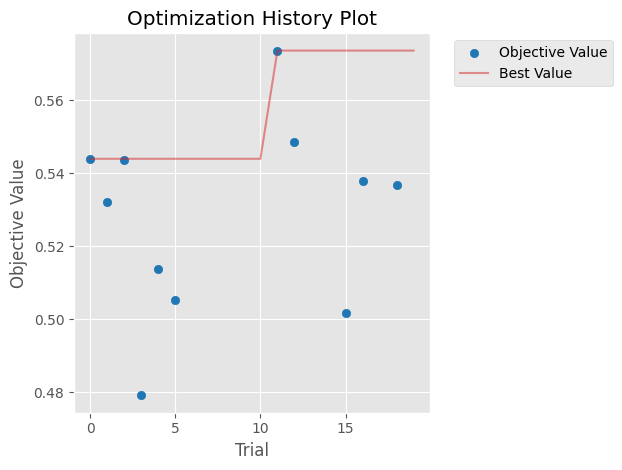

/tmp/ipykernel_1165483/3219475598.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_fn(study)


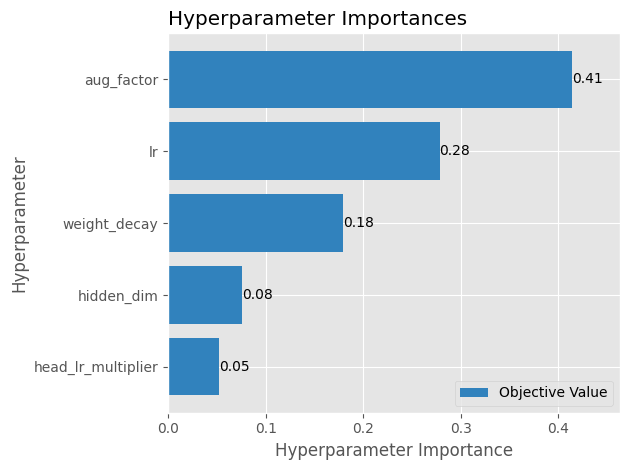

/tmp/ipykernel_1165483/3219475598.py:6: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  plot_fn(study)
/home/jlc/anaconda3/envs/mlenv/lib/python3.10/site-packages/optuna/visualization/matplotlib/_parallel_coordinate.py:115: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(dim.range[0], dim.range[1])
/home/jlc/anaconda3/envs/mlenv/lib/python3.10/site-packages/optuna/visualization/matplotlib/_parallel_coordinate.py:115: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(dim.range[0], dim.range[1])
/home/jlc/anaconda3/envs/mlenv/lib/python3.10/site-packages/optuna/visualization/matplotlib/_parallel_coordinate.py:115: UserWarning: Attempting to set identical low and high ylims makes transformation s

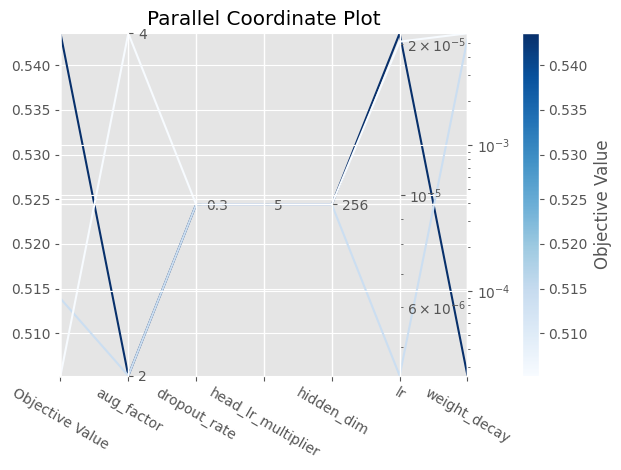

2026-03-03 02:12:48,183 INFO:	HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-03 02:12:48,192 INFO:	HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json "HTTP/1.1 200 OK"
2026-03-03 02:12:48,286 INFO:	HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-03-03 02:12:48,383 INFO:	HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base "HTTP/1.1 200 OK"
2026-03-03 02:12:48,484 INFO:	HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/commits/main "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

2026-03-03 02:12:48,607 INFO:	HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/discussions?p=0 "HTTP/1.1 200 OK"
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ign


H_AUGMENTATION — Dev Set Results (threshold=0.425)
              precision    recall  f1-score   support

     Non-PCL       0.95      0.93      0.94      1894
         PCL       0.44      0.55      0.49       199

    accuracy                           0.89      2093
   macro avg       0.70      0.74      0.71      2093
weighted avg       0.90      0.89      0.90      2093

Best hyperparams:
  lr: 2.269753767666658e-05
  weight_decay: 1.1137414908293512e-05
  hidden_dim: 0
  head_lr_multiplier: 1
  aug_factor: 1
  pooling: mean (fixed)
  warmup_fraction: 0.10 (fixed)
  label_smoothing: 0.0 (fixed)


In [6]:
for plot_fn, suffix in [
    (plot_optimization_history, "history"),
    (plot_param_importances, "importances"),
    (plot_parallel_coordinate, "parallel"),
]:
    plot_fn(study)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{EXP_NAME}_optuna_{suffix}.png", dpi=300)
    plt.show()

best = study.best_trial
best_params = best.params

model = PCLDeBERTa(
    hidden_dim=best_params["hidden_dim"],
    dropout_rate=best_params.get("dropout_rate", 0.0),
    pooling=POOLING,
).to(DEVICE)

state_dict = torch.load(
    os.path.join(OUT_DIR, f"exp_{EXP_NAME}_best_model.pt"), map_location=DEVICE
)
model.load_state_dict(state_dict)

_, _, dev_loader = make_dataloaders(
    train_sub_df, val_sub_df, dev_df, BATCH_SIZE, MAX_LENGTH, tokeniser
)

best_threshold = best.user_attrs["best_threshold"]
dev_metrics = evaluate(model, DEVICE, dev_loader, threshold=best_threshold)

print(f"\n{'='*60}")
print(f"{EXP_NAME.upper()} — Dev Set Results (threshold={best_threshold:.3f})")
print(f"{'='*60}")
print(classification_report(dev_metrics["labels"], dev_metrics["preds"],
                             target_names=["Non-PCL", "PCL"]))
print("Best hyperparams:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"  pooling: mean (fixed)")
print(f"  warmup_fraction: 0.10 (fixed)")
print(f"  label_smoothing: 0.0 (fixed)")

del model
gc.collect()
torch.cuda.empty_cache()